# Day 1 — Introduction to Machine Learning (Hands-on)
### ML Bootcamp · Day 1 of 5

Welcome! In this notebook you will:

1. Get comfortable with **Google Colab**
2. Refresh the **Python essentials** you need this week
3. Meet a real dataset and learn the words **feature**, **label**, **sample**
4. See **how a machine learns**, step by step, with a tiny example you can watch
5. Train your **first machine learning model** in about 10 lines
6. Get a sneak peek at **unsupervised learning**

> **How to use this notebook:** Read each text cell, then click the code cell below it and press **Shift + Enter** to run it. Run the cells **in order**, from top to bottom.
>
> 🧠 **Think about it** boxes are questions to discuss with your neighbour.
> ✍️ **Exercise** boxes are for you to try. Solutions are at the very end, but try first!

---
## Part 0 · Colab warm-up

A notebook is made of **cells**:
- **Text cells** (like this one) explain things.
- **Code cells** hold Python code. Run a code cell with **Shift + Enter**. The output appears right under it.

Run the cell below. If you see the message, you're ready.

In [1]:
print("Hello, Machine Learning! 👋")

Hello, Machine Learning! 👋


The **last line** of a code cell is shown automatically, even without `print`. Try it:

In [2]:
2 + 3

5

---
## Part 1 · Python essentials (quick refresher)

We only need a small part of Python this week. If something here is new to you, don't panic — you'll see it again every day.

### 1.1 Variables and types
A **variable** is a name that stores a value. Python works out the **type** by itself.

In [3]:
name = "Ada"          # text          -> str
age = 20              # whole number  -> int
gpa = 4.6             # decimal       -> float
is_student = True     # True / False  -> bool

print(name, age, gpa, is_student)
print(type(name), type(age), type(gpa), type(is_student))

Ada 20 4.6 True
<class 'str'> <class 'int'> <class 'float'> <class 'bool'>


**f-strings** let you put variables inside text. Put an `f` before the quotes and the variable inside `{ }`:

In [4]:
print(f"{name} is {age} years old and has a GPA of {gpa}")

Ada is 20 years old and has a GPA of 4.6


### 1.2 Lists — an ordered collection
Lists hold many values in order. **Counting starts at 0**, so the first item is `[0]`.

In [5]:
temps = [31, 29, 33, 35, 28]   # daily temperatures in °C

print("First day:", temps[0])
print("Last day:", temps[-1])      # -1 means "the last one"
print("First three days:", temps[0:3])
print("Number of days:", len(temps))

temps.append(30)                   # add a new value at the end
print("After append:", temps)

First day: 31
Last day: 28
First three days: [31, 29, 33]
Number of days: 5
After append: [31, 29, 33, 35, 28, 30]


### 1.3 Dictionaries — look things up by name
A dictionary stores **key → value** pairs. Very similar to one row of a table.

In [7]:
student = {"name": "Ada", "level": 200, "department": "Electrical Engineering"}

print(student["name"])
print(student["level"])

student["gpa"] = 4.6        # add a new key
print(student)

Ada
200
{'name': 'Ada', 'level': 200, 'department': 'Electrical Engineering', 'gpa': 4.6}


### 1.4 Loops and conditions
A `for` loop repeats code for every item. `if / else` makes decisions.

⚠️ **Indentation matters in Python.** The 4 spaces are what put a line *inside* the loop or the `if`.

In [8]:
for t in temps:
    if t > 30:
        print(t, "°C -> hot")
    else:
        print(t, "°C -> okay")

31 °C -> hot
29 °C -> okay
33 °C -> hot
35 °C -> hot
28 °C -> okay
30 °C -> okay


### 1.5 Functions — reusable pieces of code
Define a function with `def`, give it inputs, and `return` a result.

In [9]:
def to_fahrenheit(c):
    return c * 9 / 5 + 32

print(to_fahrenheit(30))
print(to_fahrenheit(100))

86.0
212.0


> ✍️ **Exercise 1**
> 1. Create a list called `temps_f` that holds every value in `temps` converted to °F. *(Hint: start with an empty list `[]`, loop over `temps`, and `append`.)*
> 2. Write a function `average(numbers)` that returns the average of a list. *(Hint: `sum()` and `len()`.)*
> 3. Use your function to print the average temperature in °C.

In [10]:
# ✍️ Your code for Exercise 1 here

---
## Part 2 · Meet a real dataset — the Iris flowers 🌸

The **Iris dataset** is the "hello world" of machine learning. A botanist measured **150 iris flowers** from **3 species** (*setosa*, *versicolor*, *virginica*). For each flower we have **4 measurements** in cm:

| sepal length | sepal width | petal length | petal width |
|---|---|---|---|

Our question: **can a computer tell the species just from the measurements?**

It comes built into **scikit-learn**, the main library for classic ML. We'll load it into a **Pandas DataFrame** (a table — you'll learn Pandas properly tomorrow).

In [11]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame                                  # the full table
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))

df.head()      # show the first 5 rows

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### 2.1 The key words, on real data
- Each **row** is one flower → one **sample**.
- The 4 measurement columns are the **features** (the inputs).
- The `species` column is the **label** (what we want to predict). `target` is the same thing written as a number: 0, 1 or 2.

In [12]:
print("Shape (rows, columns):", df.shape)
print()
print("Features:", iris.feature_names)
print("Label names:", [str(n) for n in iris.target_names])
print()
print("How many flowers of each species?")
print(df["species"].value_counts())

Shape (rows, columns): (150, 6)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Label names: ['setosa', 'versicolor', 'virginica']

How many flowers of each species?
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


### 2.2 Look at the data before modelling
A good ML engineer always **looks** at the data first (this is called **EDA**, Exploratory Data Analysis — a big part of Day 2).

Below we plot petal length against petal width, coloured by species.

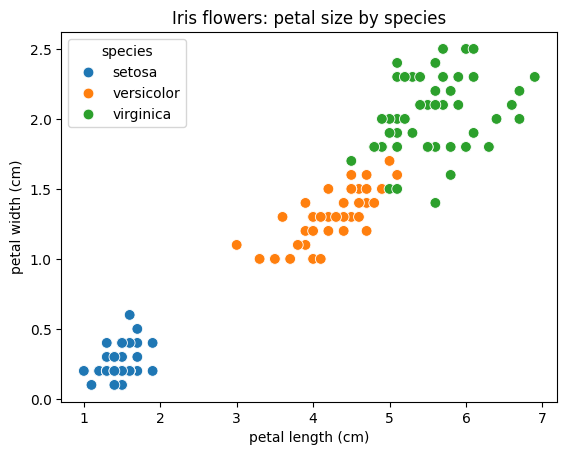

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(data=df, x="petal length (cm)", y="petal width (cm)", hue="species", s=60)
plt.title("Iris flowers: petal size by species")
plt.show()

> 🧠 **Think about it**
> - Which species is easiest to separate from the others?
> - If I gave you a flower with a petal length of 1.5 cm, which species would you guess? Why?
>
> You just did "machine learning" in your head: you learned a **rule from examples**. Now let's get the computer to do it.

---
## Part 3 · How does a machine learn? (watch it happen)

Remember the loop from the slides:

**1. Show examples → 2. Make a guess → 3. Measure the error → 4. Adjust & repeat**

Let's watch it on a tiny made-up problem: predicting **house price (₦ millions)** from **size (m²)**. We'll assume the rule is simply

$$\text{price} = w \times \text{size}$$

and the computer must **learn the best value of `w`**. It starts with a bad guess and improves it step by step.

In [14]:
import numpy as np

# Made-up training data: size (m²) and real price (₦ millions)
size  = np.array([50, 80, 100, 120, 150, 200])
price = np.array([26, 41, 49, 61, 74, 101])

w = 0.1               # step 0: a bad starting guess
learning_rate = 0.00002
errors = []

for step in range(15):
    guess = w * size                          # 2. make a guess
    error = np.mean((guess - price) ** 2)     # 3. measure the error (mean squared error)
    errors.append(error)
    # 4. adjust w a little in the direction that reduces the error
    w = w - learning_rate * np.mean(2 * (guess - price) * size)
    print(f"step {step:2d}:  w = {w:.4f}   error = {error:10.2f}")

step  0:  w = 0.3568   error =    2582.33
step  1:  w = 0.4496   error =     337.96
step  2:  w = 0.4831   error =      44.93
step  3:  w = 0.4952   error =       6.68
step  4:  w = 0.4996   error =       1.68
step  5:  w = 0.5012   error =       1.03
step  6:  w = 0.5018   error =       0.94
step  7:  w = 0.5020   error =       0.93
step  8:  w = 0.5020   error =       0.93
step  9:  w = 0.5021   error =       0.93
step 10:  w = 0.5021   error =       0.93
step 11:  w = 0.5021   error =       0.93
step 12:  w = 0.5021   error =       0.93
step 13:  w = 0.5021   error =       0.93
step 14:  w = 0.5021   error =       0.93


Look at the **error** column: it drops quickly and then settles. The computer has **learned** that each m² is worth roughly ₦0.5 million in this made-up data. Let's visualise it:

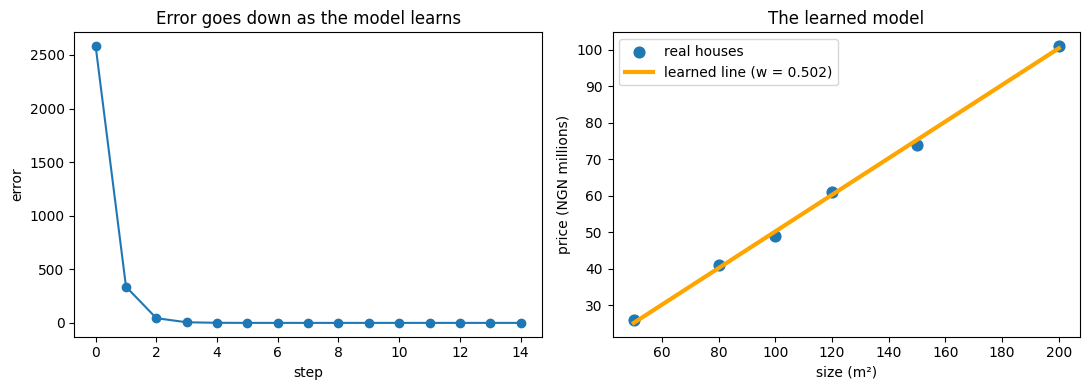

Predicted price for a 90 m² house: ₦45.2 million


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(errors, marker="o")
axes[0].set_title("Error goes down as the model learns")
axes[0].set_xlabel("step")
axes[0].set_ylabel("error")

axes[1].scatter(size, price, label="real houses", s=60)
axes[1].plot(size, w * size, color="orange", linewidth=3, label=f"learned line (w = {w:.3f})")
axes[1].set_title("The learned model")
axes[1].set_xlabel("size (m²)")
axes[1].set_ylabel("price (NGN millions)")
axes[1].legend()

plt.tight_layout()
plt.show()

new_house = 90
print(f"Predicted price for a {new_house} m² house: ₦{w * new_house:.1f} million")

> 🧠 **Think about it**
> - What happens if you change `learning_rate` to `0.0001` (5 times bigger)? Try it and re-run the cell. *(Hint: sometimes taking bigger steps overshoots!)*
> - What if you start with `w = 5`?
>
> This "guess → error → adjust" loop is called **gradient descent**. It's how almost every ML model, including ChatGPT, is trained. We'll meet it properly on Day 4.

---
## Part 4 · Your first real ML model 🎉

Now we let **scikit-learn** do the learning on the Iris flowers. Every scikit-learn model follows the same 4 steps:

| Step | Code |
|---|---|
| 1. Load data | `X, y = ...` |
| 2. Split into train and test | `train_test_split(...)` |
| 3. Train | `model.fit(X_train, y_train)` |
| 4. Test | `model.score(X_test, y_test)` |

**Why split?** We keep 20% of the flowers hidden during training. Testing on flowers the model has **never seen** tells us if it truly learned — like an exam with new questions, not past questions it memorised.

In [16]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 1. Load: X = features (measurements), y = labels (species as 0, 1, 2)
X, y = load_iris(return_X_y=True)

# 2. Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training flowers:", len(X_train), "| Test flowers:", len(X_test))

# 3. Train
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# 4. Test
accuracy = model.score(X_test, y_test)
print(f"Accuracy on unseen flowers: {accuracy:.2f}  ({accuracy*100:.0f}%)")

Training flowers: 120 | Test flowers: 30
Accuracy on unseen flowers: 1.00  (100%)


### 4.1 Compare predictions with the truth

In [17]:
predictions = model.predict(X_test)

results = pd.DataFrame({
    "real species": iris.target_names[y_test],
    "predicted": iris.target_names[predictions],
})
results["correct?"] = results["real species"] == results["predicted"]
results.head(10)

,real species,predicted,correct?
0,versicolor,versicolor,True
1,setosa,setosa,True
2,virginica,virginica,True
3,versicolor,versicolor,True
4,versicolor,versicolor,True
5,setosa,setosa,True
6,versicolor,versicolor,True
7,virginica,virginica,True
8,versicolor,versicolor,True
9,versicolor,versicolor,True


### 4.2 Predict a brand-new flower
Imagine you measured a flower in the university garden. The model can now tell you its species:

In [18]:
# sepal length, sepal width, petal length, petal width (cm)
new_flower = [[5.0, 3.4, 1.5, 0.2]]

pred = model.predict(new_flower)[0]
print("This flower is probably:", iris.target_names[pred])

This flower is probably: setosa


### 4.3 What did the tree learn?
A decision tree learns a set of **if/else rules** — exactly the "rules" from the *Traditional programming vs ML* slide, except the computer wrote them!

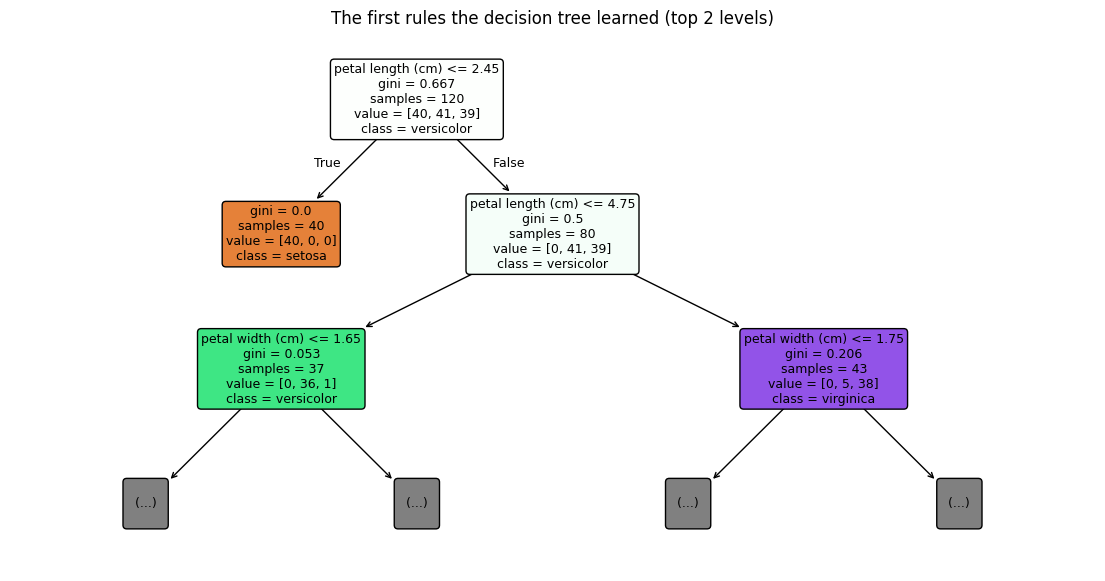

In [19]:
from sklearn.tree import plot_tree

plt.figure(figsize=(14, 7))
plot_tree(model, feature_names=iris.feature_names, class_names=list(iris.target_names),
          filled=True, rounded=True, fontsize=9, max_depth=2)
plt.title("The first rules the decision tree learned (top 2 levels)")
plt.show()

> 🧠 **Think about it**
> Look at the very first rule at the top of the tree. Does it match what you noticed in the scatter plot in Part 2?

### 4.4 Swapping models is one line
The same 4-step pattern works for **every** scikit-learn model. Here's **K-Nearest Neighbours (KNN)**, which classifies a flower by looking at the most similar flowers it has seen.

In [20]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print(f"KNN accuracy: {knn.score(X_test, y_test):.2f}")

KNN accuracy: 1.00


> ✍️ **Exercise 2**
> 1. Change `test_size` to `0.5` in the Part 4 cell and re-run it. Does the accuracy change? Why might it?
> 2. Try `KNeighborsClassifier(n_neighbors=1)` and `n_neighbors=15`. Which works best here?
> 3. Predict the species of a flower with measurements `[6.7, 3.0, 5.2, 2.3]`.

In [21]:
# ✍️ Your code for Exercise 2 here

---
## Part 5 · Sneak peek: unsupervised learning

What if **nobody told us the species**? In **unsupervised learning** we give the model only the features — **no labels** — and ask it to find groups by itself.

**K-Means** clustering will look for 3 groups of similar flowers. Then we'll compare its groups with the real species (which it never saw).

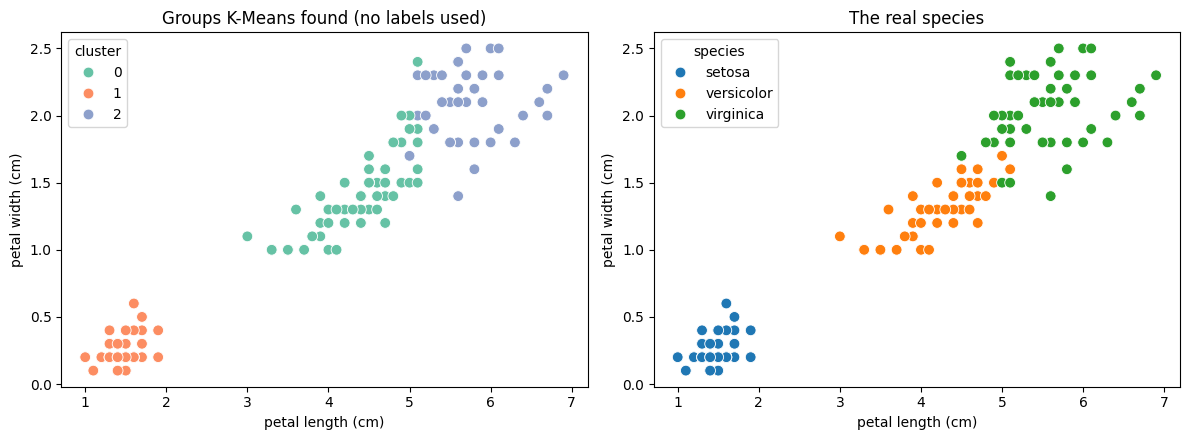

In [22]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X)      # note: only X, no y!

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(data=df, x="petal length (cm)", y="petal width (cm)", hue="cluster",
                palette="Set2", s=60, ax=axes[0])
axes[0].set_title("Groups K-Means found (no labels used)")
sns.scatterplot(data=df, x="petal length (cm)", y="petal width (cm)", hue="species",
                s=60, ax=axes[1])
axes[1].set_title("The real species")
plt.tight_layout()
plt.show()

> 🧠 **Think about it**
> The cluster numbers (0, 1, 2) are just names — K-Means doesn't know what "setosa" means. But do its **groups** look similar to the real species? Where does it get confused?
>
> We'll go much deeper into clustering on **Day 3**.

---
## 🎯 Recap

Today you:
- ran Python in **Colab** and refreshed **variables, lists, dictionaries, loops, functions**
- met the words **sample, feature, label** on a real dataset
- **watched** a model learn: guess → error → adjust → repeat
- trained a **supervised** model (decision tree, then KNN) with **fit → predict → score**
- tried **unsupervised** learning with K-Means

**Tomorrow (Day 2):** NumPy, Pandas and Seaborn in depth, EDA on messy real data (Titanic), feature engineering, and regression & classification.

---
## ✅ Solutions (try the exercises first!)

In [23]:
# Exercise 1
temps_f = []
for t in temps:
    temps_f.append(to_fahrenheit(t))
print("In °F:", temps_f)

def average(numbers):
    return sum(numbers) / len(numbers)

print(f"Average temperature: {average(temps):.1f} °C")

In °F: [87.8, 84.2, 91.4, 95.0, 82.4, 86.0]
Average temperature: 31.0 °C


In [24]:
# Exercise 2
# 1. With test_size=0.5 the model trains on fewer flowers (75 instead of 120),
#    and the test set is different, so accuracy can go up or down a little.
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.5, random_state=42)
tree2 = DecisionTreeClassifier(random_state=42).fit(X_train2, y_train2)
print(f"Tree accuracy with 50% test: {tree2.score(X_test2, y_test2):.2f}")

# 2. Different numbers of neighbours.
#    Iris is an easy dataset, so on this split k=1, 5 and 15 all score the same.
#    On harder datasets the choice of k matters a lot (more on Day 3).
for k in [1, 5, 15]:
    knn_k = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    print(f"KNN with k={k:2d}: accuracy {knn_k.score(X_test, y_test):.2f}")

# 3. Predict a new flower
print("Prediction:", iris.target_names[model.predict([[6.7, 3.0, 5.2, 2.3]])[0]])

Tree accuracy with 50% test: 0.91
KNN with k= 1: accuracy 1.00
KNN with k= 5: accuracy 1.00
KNN with k=15: accuracy 1.00
Prediction: virginica
